# MBA em Data Mining — Dia 2: Treinamento de Modelos (Machine Learning)

### [Prof. Otávio Parraga](mailto:otavio.parraga@pucrs.br)

---

O notebook tem duas partes:

- **Parte A — Classificação de Churn (aprendizado supervisionado):** prever *quais
  clientes têm risco de deixar a Tramontina*, para que o time comercial possa agir antes.
- **Parte B — Segmentação com k-Means (aprendizado não supervisionado):** descobrir
  *grupos naturais de clientes* a partir do comportamento de compra, sem nenhum rótulo
  pré-definido.

## 0. Preparação do ambiente

Usamos apenas bibliotecas básicas e modelos simples:
`pandas`, `numpy`, `matplotlib` e `scikit-learn` (k-NN, Árvore, Regressão Logística,
Random Forest, k-Means).

Fixamos `random_state=42` em tudo para que os resultados sejam **reprodutíveis** —
qualquer pessoa que rodar o notebook obtém exatamente os mesmos números.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


def carregar_csv(nome_arquivo):
    """Carrega um CSV procurando primeiro em 'Dados/<arquivo>' e depois em '<arquivo>'.

    No Colab o aluno faz upload do arquivo (fica na raiz). Localmente os arquivos
    ficam na pasta Dados/. O parâmetro encoding='utf-8-sig' remove o BOM que vem
    no cabeçalho da primeira coluna.
    """
    for caminho in (os.path.join("Dados", nome_arquivo), nome_arquivo):
        if os.path.exists(caminho):
            print(f"Carregando: {caminho}")
            return pd.read_csv(caminho, encoding="utf-8-sig")
    raise FileNotFoundError(
        f"Não encontrei '{nome_arquivo}'. No Colab, faça o upload do arquivo primeiro."
    )

---
# Parte A — Classificação de Churn

**Pergunta de negócio:** quais clientes correm risco de deixar de comprar da Tramontina (churn)? 

Se conseguirmos prever isso, o time comercial pode oferecer condições especiais, suporte ou contato proativo **antes** de perder o cliente.

Isto é **aprendizado supervisionado**: temos uma variável-alvo conhecida (`Churn` ="Sim"/"Não") e ensinamos o modelo a partir de exemplos do passado.

## A.1 Carregamento e visão geral

In [2]:
clientes = carregar_csv("../Dados/tramontina_clientes.csv")
print("Formato (linhas, colunas):", clientes.shape)
clientes.head()

Carregando: ../Dados/tramontina_clientes.csv
Formato (linhas, colunas): (260, 24)


,ID_Cliente,Regiao,Canal_Venda,Porte_Cliente,Segmento,Tempo_Relacionamento_meses,Recencia_dias,Frequencia_pedidos_ano,Ticket_Medio_R$,N_Categorias_Compradas,Faturamento_Anual_R$,Desconto_Medio_%,Satisfacao_NPS_1a10,Chamados_Suporte_ano,Atraso_Medio_Pagamento_dias,Comprou_Cutelaria,Comprou_Panelas,Comprou_Utilidades_Cozinha,Comprou_Ferramentas,Comprou_Eletroportateis,Comprou_Moveis,Comprou_Talheres,Comprou_Jardinagem,Churn
0,TRM1000,Nordeste,Varejo Físico,Grande,Doméstico,39,46,32,760.32,2,26864.41,1.1,7.3,5,3,0,1,1,0,0,0,0,0,Sim
1,TRM1001,Sudeste,Marketplace,Pequeno,Corporativo,25,45,8,259.22,7,3016.26,10.2,NaN,5,6,1,1,1,1,0,1,1,1,Sim
2,TRM1002,Norte,E-commerce,Pequeno,Doméstico,40,12,7,191.00,3,1279.56,NaN,8.2,2,2,1,1,0,0,0,0,1,0,Não
3,TRM1003,Nordeste,Varejo Físico,Médio,Profissional/Food Service,69,208,14,511.54,3,7057.75,2.3,7.4,3,19,1,0,1,0,0,0,1,0,Sim
4,TRM1004,Sul,Atacado,Pequeno,Corporativo,9,48,8,224.20,6,2194.39,7.2,7.5,8,0,1,1,1,1,0,0,1,1,Não


### Balanceamento das classes

Vamos olhar a proporção de clientes que deram churn. Esse passo é decisivo: se a base
for **desbalanceada** (muito mais "Não" do que "Sim"), a **acurácia** se torna
enganosa.

> Exemplo: se 72% dos clientes **não** dão churn, um modelo preguiçoso que sempre
> responde "Não" acerta 72% das vezes — alta acurácia, mas **inútil**, porque nunca
> identifica quem vai embora. Por isso, mais adiante, vamos olhar **Recall, F1 e AUC**,
> não só a acurácia. *(slide "Quando a acurácia engana")*

Contagem:
 Churn
Não    188
Sim     72
Name: count, dtype: int64 

Proporção:
 Churn
Não    0.723
Sim    0.277
Name: proportion, dtype: float64


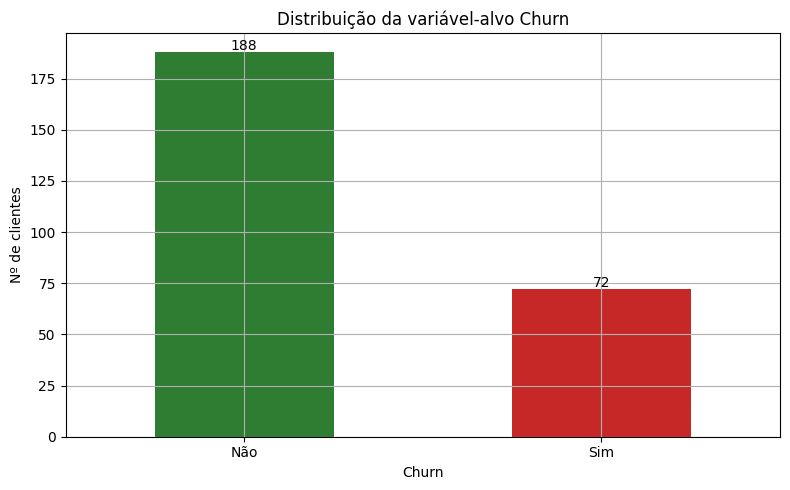


Acurácia de um modelo 'preguiçoso' (sempre prevê a maioria): 72.3%


In [3]:
contagem = clientes["Churn"].value_counts()
proporcao = clientes["Churn"].value_counts(normalize=True).round(3)
print("Contagem:\n", contagem, "\n")
print("Proporção:\n", proporcao)

fig, ax = plt.subplots()
contagem.plot(kind="bar", ax=ax, color=["#2e7d32", "#c62828"])
ax.set_title("Distribuição da variável-alvo Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Nº de clientes")
ax.set_xticklabels(contagem.index, rotation=0)
for i, v in enumerate(contagem):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()

baseline = proporcao.max()
print(f"\nAcurácia de um modelo 'preguiçoso' (sempre prevê a maioria): {baseline:.1%}")

## A.2 Definição de X, y e dos tipos de coluna

Separamos a variável-alvo (`Churn`) das variáveis preditoras (X). O modelo só entende números, então mapeamos `Não → 0` e `Sim → 1` (1 = o evento que nos interessa prever: o cliente que vai embora).

Também classificamos cada coluna por tipo, pois cada tipo recebe um tratamento diferente no pré-processamento:

- **Numéricas** → imputar ausentes (mediana) + padronizar.
- **Ordinal** (`Porte_Cliente`): tem ordem natural Pequeno < Médio < Grande → 1, 2, 3.
- **Nominais** (`Regiao`, `Canal_Venda`, `Segmento`): sem ordem → one-hot.
- **Identificador** (`ID_Cliente`): não tem valor preditivo → **descartar**.

In [4]:
# Alvo: mapeia para 0/1 (1 = churn, o evento de interesse)
y = clientes["Churn"].map({"Não": 0, "Sim": 1})

# Preditoras: tudo menos o alvo e o identificador
X = clientes.drop(columns=["Churn", "ID_Cliente"])

# Tipos de coluna (dirigem o ColumnTransformer mais adiante)
col_ordinal = ["Porte_Cliente"]
col_nominais = ["Regiao", "Canal_Venda", "Segmento"]
col_numericas = [c for c in X.columns if c not in col_ordinal + col_nominais]

print(f"{len(col_numericas)} numéricas:", col_numericas)
print(f"\n{len(col_ordinal)} ordinal:", col_ordinal)
print(f"{len(col_nominais)} nominais:", col_nominais)
print("\nValores ausentes por coluna (só as que têm):")
print(X.isna().sum()[X.isna().sum() > 0])

18 numéricas: ['Tempo_Relacionamento_meses', 'Recencia_dias', 'Frequencia_pedidos_ano', 'Ticket_Medio_R$', 'N_Categorias_Compradas', 'Faturamento_Anual_R$', 'Desconto_Medio_%', 'Satisfacao_NPS_1a10', 'Chamados_Suporte_ano', 'Atraso_Medio_Pagamento_dias', 'Comprou_Cutelaria', 'Comprou_Panelas', 'Comprou_Utilidades_Cozinha', 'Comprou_Ferramentas', 'Comprou_Eletroportateis', 'Comprou_Moveis', 'Comprou_Talheres', 'Comprou_Jardinagem']

1 ordinal: ['Porte_Cliente']
3 nominais: ['Regiao', 'Canal_Venda', 'Segmento']

Valores ausentes por coluna (só as que têm):
Desconto_Medio_%        8
Satisfacao_NPS_1a10    12
dtype: int64


Confirmamos os **valores ausentes**: `Desconto_Medio_%` e `Satisfacao_NPS_1a10`.
Vamos imputá-los com a **mediana** — mas atenção: a mediana será calculada **apenas no
conjunto de treino** (veja a próxima seção sobre vazamento de dados).

## A.3 Divisão treino / teste

Antes de qualquer ajuste, separamos os dados. Esta é a regra de ouro contra o **vazamento de dados (data leakage)**:

Se calculássemos a mediana (ou a média/desvio da padronização) usando a base inteira,
estaríamos "espiando" o conjunto de teste — o modelo pareceria melhor do que é de
verdade. *(slide "Vazamento de dados")*

- **Treino:** o modelo aprende aqui (e também validamos com validação cruzada).
- **Teste:** fica "lacrado", só é usado **no final**, para estimar o desempenho real
  em clientes novos.

Usamos `stratify=y` para manter a **mesma proporção de churn** nos dois conjuntos —
essencial em base desbalanceada.

In [5]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.25,  # 25% reservado para teste
    stratify=y,  # mantém a proporção de churn
    random_state=RANDOM_STATE,
)

print(f"Treino: {X_treino.shape[0]} clientes | Teste: {X_teste.shape[0]} clientes")
print(
    "\nProporção de churn — treino:",
    round(y_treino.mean(), 3),
    "| teste:",
    round(y_teste.mean(), 3),
)

Treino: 195 clientes | Teste: 65 clientes

Proporção de churn — treino: 0.277 | teste: 0.277


## A.4 Pipeline de pré-processamento

Montamos um `ColumnTransformer` que aplica a cada tipo de coluna o tratamento certo.

Ele é encaixado dentro de um `Pipeline` junto com o modelo. O pré-processamento é ajustado apenas no treino automaticamente, dentro da validação
cruzada, isso acontece a cada *fold*, sem nenhum vazamento.

A padronização é importante para modelos baseados em distância (k-NN) e para a Regressão Logística.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Numéricas: imputa mediana + padroniza
prep_numericas = Pipeline(
    [
        ("imputar", SimpleImputer(strategy="median")),
        ("padronizar", StandardScaler()),
    ]
)

# Ordinal: imputa a categoria mais frequente + codifica respeitando a ordem
prep_ordinal = Pipeline(
    [
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(categories=[["Pequeno", "Médio", "Grande"]])),
    ]
)

# Nominais: imputa a mais frequente + one-hot
prep_nominais = Pipeline(
    [
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessador = ColumnTransformer(
    [
        ("num", prep_numericas, col_numericas),
        ("ord", prep_ordinal, col_ordinal),
        ("nom", prep_nominais, col_nominais),
    ]
)

## A.5 Treinar vários modelos diferentes

Não existe "o melhor modelo" universal, depende dos dados. Por isso treinamos quatro modelos distintos, todos embrulhados no mesmo pipeline de pré-processamento, e depois os comparamos de forma justa.

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelos = {
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Árvore de Decisão": DecisionTreeClassifier(
        max_depth=5, random_state=RANDOM_STATE
    ),  # poda: limita a profundidade
    "Regressão Logística": LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE
    ),  # iterações suficientes p/ convergir
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE
    ),
}

# Cada modelo vira: pré-processamento -> classificador
pipelines = {
    nome: Pipeline([("prep", preprocessador), ("modelo", modelo)])
    for nome, modelo in modelos.items()
}

print("Pipelines prontos:", list(pipelines.keys()))

Pipelines prontos: ['k-NN', 'Árvore de Decisão', 'Regressão Logística', 'Random Forest']


## A.6 Avaliação e comparação com validação cruzada (k-fold)

Para comparar os modelos de forma justa e estável, usamos validação cruzada estratificada com k=5 apenas no conjunto de treino. A base é dividida em 5 partes; o modelo treina em 4 e valida na 5ª, repetindo 5 vezes. A média reduz o efeito da "sorte" de uma única divisão. 

Reportamos cinco métricas:

- **Acurácia** = acertos totais (pode enganar em base desbalanceada).
- **Precisão** = dos que previu churn, quantos realmente eram.
- **Recall (Sensibilidade)** = dos que de fato deram churn, quantos o modelo pegou.
- **F1** = média harmônica de Precisão e Recall (equilíbrio).
- **AUC** = capacidade de **ranquear** clientes por risco (1,0 = perfeito; 0,5 = chute).

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas = {
    "Acurácia": "accuracy",
    "Precisão": make_scorer(precision_score, zero_division=0),
    "Recall": "recall",
    "F1": "f1",
    "AUC": "roc_auc",
}

linhas = []
for nome, pipe in pipelines.items():
    resultado = cross_validate(pipe, X_treino, y_treino, cv=cv, scoring=metricas)
    linhas.append(
        {"Modelo": nome, **{m: resultado[f"test_{m}"].mean() for m in metricas}}
    )

comparacao = pd.DataFrame(linhas).set_index("Modelo").round(3)
comparacao

,Acurácia,Precisão,Recall,F1,AUC
Modelo,,,,,
k-NN,0.672,0.367,0.200,0.256,0.566
Árvore de Decisão,0.672,0.371,0.316,0.330,0.598
Regressão Logística,0.692,0.433,0.316,0.360,0.702
Random Forest,0.744,0.550,0.167,0.255,0.722


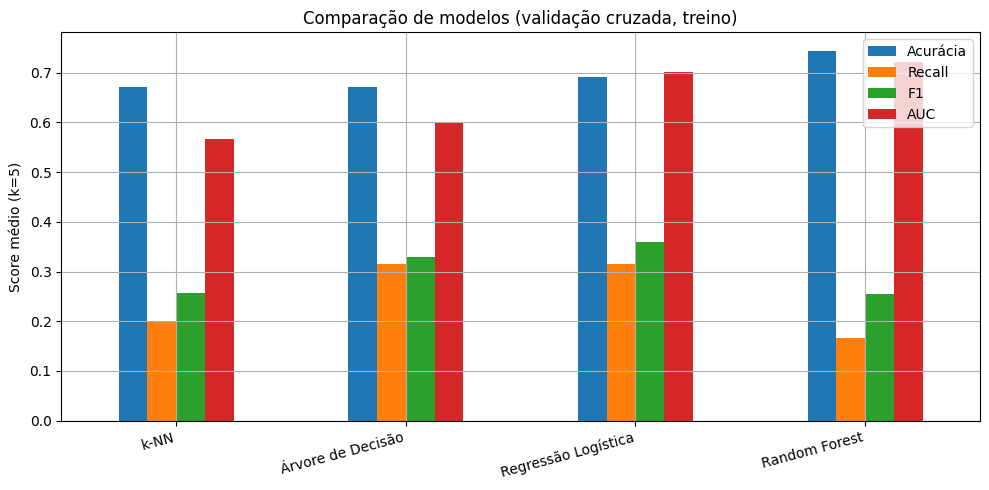

In [9]:
# Visual: comparar Acurácia x Recall x F1 x AUC
ax = comparacao[["Acurácia", "Recall", "F1", "AUC"]].plot(kind="bar", figsize=(10, 5))
ax.set_title("Comparação de modelos (validação cruzada, treino)")
ax.set_ylabel("Score médio (k=5)")
ax.set_xlabel("")
ax.set_xticklabels(comparacao.index, rotation=15, ha="right")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Escolher o modelo

Para o problema de churn, a classe "Sim" é a minoritária e a mais cara: um cliente que vai embora sem que façamos nada é receita perdida. Logo, acurácia isolada não basta, precisamos olhar Recall, F1 e AUC.

Observe a tabela:

- A **Random Forest** tem a maior **acurácia** e a maior **AUC**, mas um **Recall baixo**
  — ou seja, é "conservadora" e deixa passar muitos churns reais.
- A **Regressão Logística** entrega o melhor equilíbrio **F1** e uma **AUC** alta,
  identificando mais clientes em risco.

Como o custo de **não detectar** um churn é alto, escolhemos o modelo pelo **F1**
(equilíbrio entre pegar os churns e não disparar alarmes falsos demais). Selecionamos
automaticamente o vencedor por F1 abaixo.

In [10]:
modelo_escolhido = comparacao["F1"].idxmax()
print(f"Modelo escolhido (maior F1 na validação cruzada): {modelo_escolhido}")
print("\nResumo do escolhido:")
print(comparacao.loc[modelo_escolhido])

Modelo escolhido (maior F1 na validação cruzada): Regressão Logística

Resumo do escolhido:
Acurácia    0.692
Precisão    0.433
Recall      0.316
F1          0.360
AUC         0.702
Name: Regressão Logística, dtype: float64


## A.7 Avaliação final no conjunto de teste

Agora **retreinamos o modelo escolhido em todo o treino** e o avaliamos no conjunto de
**teste**, que ficou lacrado até aqui. Esta é a estimativa honesta de como o modelo se
comportará com **clientes novos**.

In [11]:
pipe_final = pipelines[modelo_escolhido]
pipe_final.fit(X_treino, y_treino)  # retreina em todo o treino

y_pred = pipe_final.predict(X_teste)
y_prob = pipe_final.predict_proba(X_teste)[:, 1]  # probabilidade de churn
print(
    f"Modelo final: {modelo_escolhido} — avaliado em {len(y_teste)} clientes de teste."
)

Modelo final: Regressão Logística — avaliado em 65 clientes de teste.


### Matriz de confusão

Cruza o que **aconteceu de verdade** (linhas) com o que o **modelo previu** (colunas):

- **VP** (Verdadeiro Positivo): churn previsto **e** ocorreu. ✅ Cliente salvo a tempo.
- **VN** (Verdadeiro Negativo): "fica" previsto e ficou. ✅
- **FP** (Falso Positivo): previu churn, mas o cliente ficaria. → custo de uma ação de
  retenção desnecessária (barato).
- **FN** (Falso Negativo): previu que ficaria, **mas o cliente foi embora**. → **o erro
  caro**: perdemos o cliente sem nenhuma ação de retenção.

> 🟠 **No Orange:** widget **Confusion Matrix**.

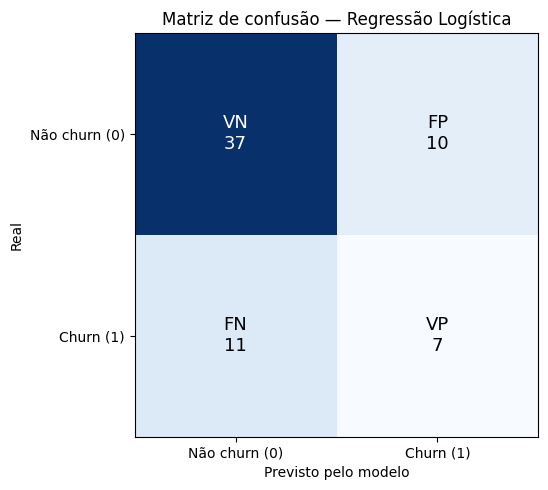

VP=7  VN=37  FP=10  FN=11


In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_teste, y_pred)  # [[VN, FP], [FN, VP]]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
rotulos = ["Não churn (0)", "Churn (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(rotulos)
ax.set_yticklabels(rotulos)
ax.set_xlabel("Previsto pelo modelo")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusão — {modelo_escolhido}")
nomes = [["VN", "FP"], ["FN", "VP"]]
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{nomes[i][j]}\n{cm[i, j]}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=13,
        )
ax.grid(False)
plt.tight_layout()
plt.show()

vn, fp, fn, vp = cm.ravel()
print(f"VP={vp}  VN={vn}  FP={fp}  FN={fn}")

### Métricas no teste (com as fórmulas)

- **Acurácia** = (VP + VN) / total
- **Precisão** = VP / (VP + FP)
- **Recall** = VP / (VP + FN)
- **F1** = 2 · (Precisão · Recall) / (Precisão + Recall)

*(slide "Métricas de classificação")*

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

print(f"Acurácia : {accuracy_score(y_teste, y_pred):.3f}")
print(f"Precisão : {precision_score(y_teste, y_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_teste, y_pred):.3f}")
print(f"F1       : {f1_score(y_teste, y_pred):.3f}")
print("\nRelatório completo:\n")
print(
    classification_report(
        y_teste, y_pred, target_names=["Não churn", "Churn"], zero_division=0
    )
)

Acurácia : 0.677
Precisão : 0.412
Recall   : 0.389
F1       : 0.400

Relatório completo:

              precision    recall  f1-score   support

   Não churn       0.77      0.79      0.78        47
       Churn       0.41      0.39      0.40        18

    accuracy                           0.68        65
   macro avg       0.59      0.59      0.59        65
weighted avg       0.67      0.68      0.67        65



### Curva ROC e AUC

A **curva ROC** mostra o equilíbrio entre **capturar churns** (taxa de verdadeiros
positivos) e **disparar alarmes falsos** (taxa de falsos positivos) à medida que
mudamos o limiar de decisão. A **AUC** (área sob a curva) resume isso num número:
quanto mais perto de **1,0**, melhor o modelo **ordena** os clientes por risco. A linha
diagonal (AUC = 0,5) é o "chute".

> 🟠 **No Orange:** widget **ROC Analysis**.

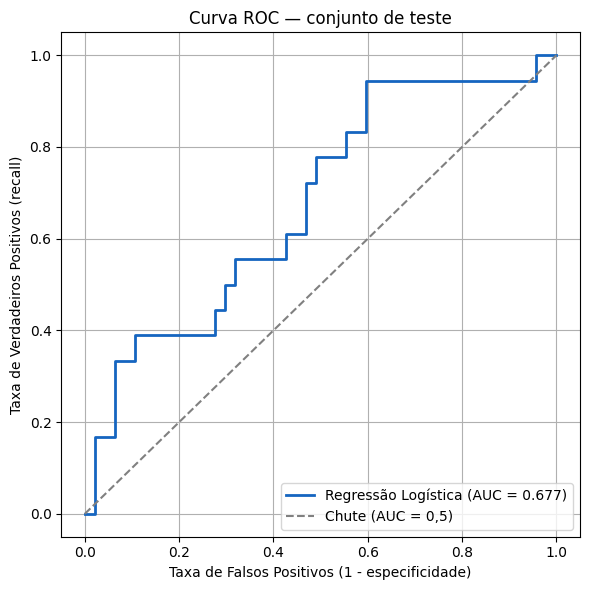

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_teste, y_prob)
auc = roc_auc_score(y_teste, y_prob)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#1565c0", lw=2, label=f"{modelo_escolhido} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Chute (AUC = 0,5)")
ax.set_xlabel("Taxa de Falsos Positivos (1 - especificidade)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (recall)")
ax.set_title("Curva ROC — conjunto de teste")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Leitura de negócio dos resultados

- Cada **VP** é um cliente em risco que o modelo **identificou** — o time comercial pode
  agir (desconto, contato, suporte) e **reter receita**.
- Cada **FN** é o erro mais doloroso: um cliente que **foi embora sem que ninguém
  agisse**. Por isso priorizamos modelos com bom **Recall/F1**.
- Os **FP** geram apenas um custo pequeno (uma ação de retenção em quem talvez ficasse) —
  num contexto de churn, costuma valer a pena.

Em resumo: o modelo não precisa ser perfeito; precisa **ranquear bem o risco** (AUC) e
**capturar os churns que importam** (Recall), para transformar previsão em **ação de
retenção**.

## A.8 Interpretabilidade — quais fatores mais explicam o churn?

Modelos baseados em árvores nos dão a **importância das variáveis**: quanto cada fator
contribuiu para separar quem dá churn de quem fica. Isso responde à pergunta do gestor:
*"o que mais influencia a saída do cliente?"*. Mesmo que a Regressão Logística tenha
vencido, treinamos aqui uma **Random Forest** e uma **Árvore rasa** só para esta leitura.

> 🟠 **No Orange:** widget **Tree Viewer** (visualiza a árvore) e **Random Forest**
> (importâncias).

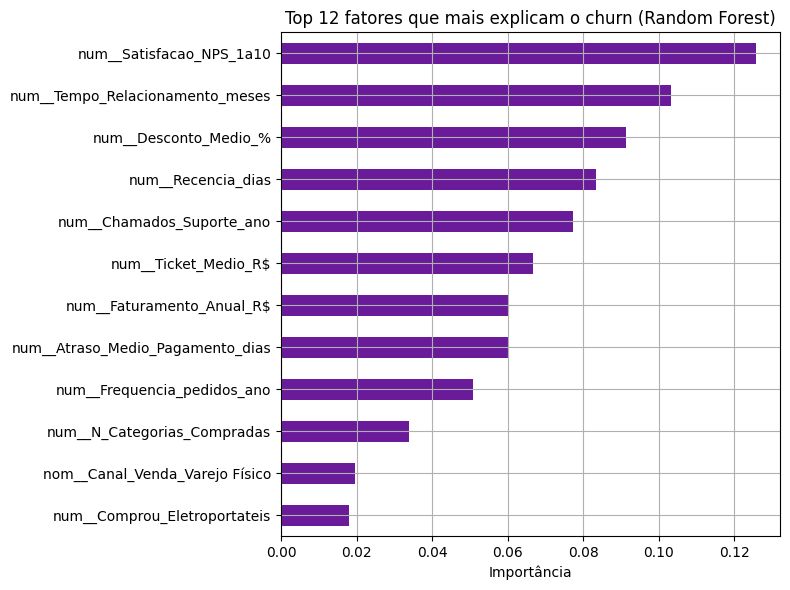

In [15]:
# Random Forest para extrair importâncias (treinada no treino)
pipe_rf = pipelines["Random Forest"].fit(X_treino, y_treino)

# Recupera os nomes das colunas após o pré-processamento (inclui one-hot)
nomes_features = pipe_rf.named_steps["prep"].get_feature_names_out()
importancias = pipe_rf.named_steps["modelo"].feature_importances_

imp = (
    pd.Series(importancias, index=nomes_features).sort_values(ascending=False).head(12)
)

ax = imp.iloc[::-1].plot(kind="barh", figsize=(8, 6), color="#6a1b9a")
ax.set_title("Top 12 fatores que mais explicam o churn (Random Forest)")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.show()

In [16]:
# Regras legíveis de uma árvore rasa (profundidade 3) — fácil de explicar ao gestor
from sklearn.tree import export_text

pipe_arvore = Pipeline(
    [
        ("prep", preprocessador),
        ("modelo", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
    ]
).fit(X_treino, y_treino)

nomes = pipe_arvore.named_steps["prep"].get_feature_names_out()
regras = export_text(pipe_arvore.named_steps["modelo"], feature_names=list(nomes))
print(regras)

|--- num__Satisfacao_NPS_1a10 <= -0.11
|   |--- num__Tempo_Relacionamento_meses <= -0.60
|   |   |--- num__Comprou_Cutelaria <= -0.53
|   |   |   |--- class: 0
|   |   |--- num__Comprou_Cutelaria >  -0.53
|   |   |   |--- class: 1
|   |--- num__Tempo_Relacionamento_meses >  -0.60
|   |   |--- num__Satisfacao_NPS_1a10 <= -1.41
|   |   |   |--- class: 1
|   |   |--- num__Satisfacao_NPS_1a10 >  -1.41
|   |   |   |--- class: 0
|--- num__Satisfacao_NPS_1a10 >  -0.11
|   |--- num__Desconto_Medio_% <= 1.67
|   |   |--- num__Tempo_Relacionamento_meses <= 0.17
|   |   |   |--- class: 0
|   |   |--- num__Tempo_Relacionamento_meses >  0.17
|   |   |   |--- class: 0
|   |--- num__Desconto_Medio_% >  1.67
|   |   |--- num__Chamados_Suporte_ano <= -0.27
|   |   |   |--- class: 0
|   |   |--- num__Chamados_Suporte_ano >  -0.27
|   |   |   |--- class: 1



---
# Parte B — Segmentação de clientes com k-Means

**Pergunta de negócio:** *existem grupos naturais de clientes com comportamentos de
compra parecidos?* Se sim, a Tramontina pode criar **estratégias específicas** para cada
grupo (atacado, varejo pequeno, cozinha profissional...).

Isto é **aprendizado não supervisionado**: **não há rótulo**. Ninguém nos disse a que
grupo cada cliente pertence — o algoritmo descobre os grupos sozinho a partir do
comportamento.

> ⚠️ Existe um arquivo `tramontina_clustering_gabarito.csv` na pasta — **não vamos usá-lo**.
> Ele é um "gabarito" e usá-lo destruiria o sentido do exercício não supervisionado.

## B.1 Carregamento e visão geral

Usaremos **5 variáveis numéricas comportamentais**:

| Variável | Significado |
|---|---|
| `Gasto_Mensal_R$` | Quanto o cliente gasta por mês |
| `Itens_por_Pedido` | Tamanho médio do pedido |
| `Frequencia_Compras_mes` | Com que frequência compra |
| `Perc_Linha_Cozinha_Profissional` | % do mix em linha profissional |
| `Anos_como_Cliente` | Tempo de relacionamento |

`Canal_Predominante` é **contexto categórico** (usaremos só para interpretar, não para
agrupar) e `ID_Cliente` é identificador.

> 🟠 **No Orange:** widget **File** → **Select Columns** (seleciona as 5 numéricas).

In [17]:
clustering = carregar_csv("tramontina_clustering.csv")
print("Formato:", clustering.shape)
clustering.head()

FileNotFoundError: Não encontrei 'tramontina_clustering.csv'. No Colab, faça o upload do arquivo primeiro.

In [ ]:
features_cluster = [
    "Gasto_Mensal_R$",
    "Itens_por_Pedido",
    "Frequencia_Compras_mes",
    "Perc_Linha_Cozinha_Profissional",
    "Anos_como_Cliente",
]
Xc = clustering[features_cluster].copy()
print("Estatísticas das variáveis usadas no agrupamento:")
Xc.describe().round(2)

## B.2 Pré-processamento — padronizar é essencial

O k-Means agrupa por **distância**. Se uma variável estiver em escala muito maior (ex.:
`Gasto_Mensal_R$` em milhares vs. `Frequencia_Compras_mes` em unidades), ela
**dominaria** o cálculo. Por isso **padronizamos** (média 0, desvio 1): assim todas as
variáveis pesam igual. *(slide "k-Means: padronizar antes")*

> 🟠 **No Orange:** widget **Preprocess** → **Normalize** (ou **Continuize**).

In [ ]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
Xc_pad = escalador.fit_transform(Xc)
print("Dados padronizados. Média ~0 e desvio ~1 em cada variável:")
print("Médias :", np.round(Xc_pad.mean(axis=0), 2))
print("Desvios:", np.round(Xc_pad.std(axis=0), 2))

## B.3 Escolher k — método do cotovelo e silhueta

Quantos grupos existem? Não sabemos de antemão. Usamos duas técnicas:

- **Cotovelo (elbow):** roda o k-Means para vários *k* e olha a **inércia** (soma das
  distâncias internas). Procuramos o "cotovelo" — o ponto a partir do qual aumentar *k*
  pouco melhora.
- **Silhueta:** mede o quão **bem separados e coesos** estão os grupos (de -1 a 1; quanto
  maior, melhor). *(slide "Escolher k: cotovelo e silhueta")*

> 🟠 **No Orange:** o widget **k-Means** já testa vários *k* e reporta a **Silhouette
> Score**; o **Silhouette Plot** detalha por cliente.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inercias, silhuetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xc_pad)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(Xc_pad, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(list(ks), inercias, "o-", color="#1565c0")
ax1.set_title("Método do cotovelo")
ax1.set_xlabel("k")
ax1.set_ylabel("Inércia")
ax2.plot(list(ks), silhuetas, "o-", color="#2e7d32")
ax2.set_title("Silhueta por k")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

for k, s in zip(ks, silhuetas):
    print(f"k={k}  silhueta={s:.3f}")

**Leitura:** o cotovelo aparece nitidamente em **k = 3** (depois disso o ganho de
inércia cai bastante) e a **silhueta é máxima em k = 3** (≈ 0,64). As duas técnicas
concordam — escolhemos **k = 3**.

## B.4 Treinar o k-Means com k = 3

Usamos `n_init=10` (10 inicializações diferentes, o algoritmo fica com a melhor) e
`random_state=42` para reprodutibilidade.

> 🟠 **No Orange:** widget **k-Means** com *Number of Clusters = 3*.

In [ ]:
K_ESCOLHIDO = 3
kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=10)
clustering["Cluster"] = kmeans.fit_predict(Xc_pad)

print("Tamanho de cada cluster:")
print(clustering["Cluster"].value_counts().sort_index())

## B.5 Visualizar os grupos com PCA

Temos 5 dimensões — impossível desenhar. A **PCA (Análise de Componentes Principais)**
projeta os dados em **2 dimensões** preservando o máximo de variação, só para
**visualizar** os grupos num gráfico de dispersão. *(slide "PCA: visualizar clusters")*

> 🟠 **No Orange:** widget **PCA** (2 componentes) → **Scatter Plot** colorido por
> cluster.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xc_pad)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
cores = ["#1565c0", "#c62828", "#2e7d32", "#f9a825"]
for c in sorted(clustering["Cluster"].unique()):
    m = clustering["Cluster"] == c
    ax.scatter(
        coords[m, 0],
        coords[m, 1],
        s=40,
        alpha=0.7,
        color=cores[c],
        label=f"Cluster {c}",
    )
ax.set_xlabel(f"Componente 1 ({var[0]:.0%} da variação)")
ax.set_ylabel(f"Componente 2 ({var[1]:.0%} da variação)")
ax.set_title("Clusters projetados em 2D via PCA")
ax.legend()
plt.tight_layout()
plt.show()
print(f"As 2 componentes explicam {var.sum():.0%} da variação total.")

## B.6 Perfilar e interpretar os clusters

O número do cluster não diz nada sozinho. Para dar **sentido de negócio**, calculamos o
**perfil médio** de cada grupo e damos um **nome**. *(slides de segmentação de clientes/
SKUs)*

In [ ]:
perfil = clustering.groupby("Cluster")[features_cluster].mean().round(1)
perfil["N_clientes"] = clustering["Cluster"].value_counts().sort_index()
perfil

In [ ]:
# Cruzamento cluster x canal predominante (insight extra de contexto)
pd.crosstab(clustering["Cluster"], clustering["Canal_Predominante"])

### Nomes de negócio para os clusters

Lendo a tabela de perfil (os números podem variar levemente conforme a versão do
scikit-learn, mas os **perfis** são estes):

- **Varejo pequeno / pulverizado** — *menor* gasto mensal, poucos itens por pedido,
  baixa frequência, baixíssimo % de linha profissional. É o **maior** grupo e compra
  sobretudo por **E-commerce e Varejo Físico**. → ações de **ticket médio** e
  recompra/automação.
- **Atacado / alto volume** — gasto mensal *muito alto*, pedidos *grandes* (dezenas de
  itens) e maior tempo de casa. Concentrado em **Atacado e Distribuidor**. → relação
  **B2B**, condições comerciais e gestão de conta-chave.
- **Profissional de cozinha** — *altíssimo* % da linha de cozinha profissional, **maior
  frequência** de compra e gasto intermediário. Vem de **Distribuidor/Atacado**. → mix
  **profissional**, fidelização técnica e lançamentos especializados.

> O cruzamento com `Canal_Predominante` **confirma** a interpretação — cada perfil tem
> um canal dominante coerente.

### Como avaliar clusters **sem rótulos**?

Sem variável-alvo não há "acurácia". Avaliamos a qualidade da segmentação por:

1. **Silhueta** — coesão interna e separação entre grupos (já vimos: ~0,64 em k=3, bom).
2. **Estabilidade** — os grupos se mantêm com outra semente/amostra?
3. **Validação do especialista** — os perfis fazem **sentido para o negócio**? Aqui sim:
   atacado, varejo pulverizado e profissional de cozinha são segmentos reais da
   Tramontina.

> O melhor *k* não é só o de maior silhueta — é o que gera grupos **acionáveis**.

---
# Encerramento — do dado à decisão

Hoje saímos do dado preparado (Dia 1) para **modelos que apoiam decisões**:

**Parte A — Churn (supervisionado):**
- Separamos treino/teste **antes** de tudo, evitando **vazamento de dados**.
- Montamos um **pipeline** que imputa, padroniza e codifica **só no treino**.
- Comparamos **quatro modelos** com **validação cruzada** e escolhemos pelo que importa
  no churn (**Recall / F1 / AUC**, não só acurácia).
- Avaliamos no teste com **matriz de confusão, métricas e curva ROC**, lendo os erros em
  **termos de negócio** (um FN = cliente perdido sem ação).
- Identificamos os **fatores que mais explicam o churn**.

**Parte B — Segmentação (não supervisionado):**
- Padronizamos e escolhemos **k = 3** por **cotovelo + silhueta**.
- Visualizamos com **PCA** e demos **nomes de negócio** aos grupos (varejo pequeno,
  atacado, profissional de cozinha).

**Tudo é reproduzível no Orange Data Mining** com os widgets indicados em cada "🟠 No
Orange" — sem escrever uma linha de código.

> **Mensagem final:** um modelo só tem valor quando vira **decisão**. Prever churn → agir
> para reter. Segmentar clientes → estratégia sob medida para cada grupo. *Do dado à
> decisão.*